In [1]:
import os
import glob
import numpy as np
import pyvista as pv
import xarray as xr
from natsort import natsorted

In [2]:
vtk_base = "outputs/openfoam_cases/0002/VTK"

In [ ]:
vtu_files = natsorted(glob.glob(os.path.join(vtk_base, "0002_*", "internal.vtu")))

times = []
free_surface_x = []
free_surface_y = []

for f in vtu_files:
    mesh = pv.read(f)

    # Extract time
    folder_name = os.path.basename(os.path.dirname(f))
    try:
        t = float(folder_name.split("_")[-1])
    except:
        t = len(times)
    times.append(t)

    # Extract iso-surface alpha = 0.5
    surf = mesh.contour(isosurfaces=[0.5], scalars="alpha.water")

    pts = surf.points   # (Npoints, 3)

    # Sort by x
    idx = np.argsort(pts[:, 0])
    x_sorted = pts[idx, 0]
    y_sorted = pts[idx, 1]

    # For each unique x, take max y
    unique_x = np.unique(x_sorted)
    eta = []

    for xval in unique_x:
        eta.append(y_sorted[x_sorted == xval].max())

    free_surface_x.append(unique_x)
    free_surface_y.append(np.array(eta))

In [ ]:
x_common = np.linspace(0, 1201, 1200)

eta_all = []

for x_fs, y_fs in zip(free_surface_x, free_surface_y):
    eta_interp = np.interp(x_common, x_fs, y_fs)
    eta_all.append(eta_interp)

eta_all = np.array(eta_all)

In [ ]:
import xarray as xr

ds_eta = xr.Dataset(
    {
        "eta": (("time", "x"), eta_all)
    },
    coords={
        "time": times,
        "x": x_common
    }
)

MovieWriter ffmpeg unavailable; using Pillow instead.


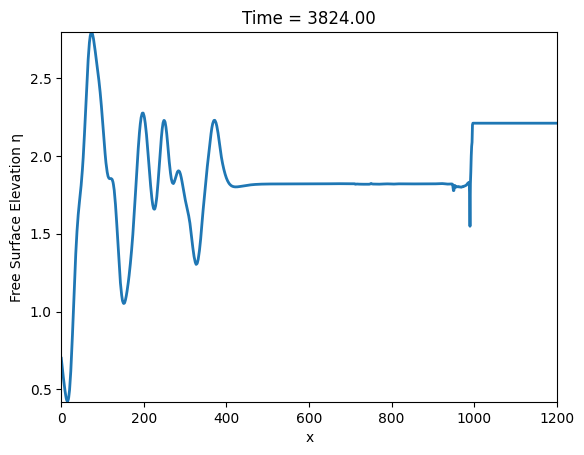

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()

line, = ax.plot([], [], lw=2)

ax.set_xlim(ds_eta.x.min().item(), ds_eta.x.max().item())
ax.set_ylim(ds_eta.eta.min().item(), ds_eta.eta.max().item())

ax.set_xlabel("x")
ax.set_ylabel("Free Surface Elevation η")

def init():
    line.set_data([], [])
    return line,

def update(frame):
    x = ds_eta.x.values
    y = ds_eta.eta.isel(time=frame).values
    line.set_data(x, y)
    ax.set_title(f"Time = {ds_eta.time.values[frame]:.2f}")
    return line,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(ds_eta.time),
    init_func=init,
    blit=True,
    interval=200  # milliseconds between frames
)
ani.save('gif.gif')
plt.show()

In [ ]:
surf = mesh.contour(isosurfaces=[0.5], scalars="alpha.water")
surf_points = surf.points   # (n_surface_points, 3)

free_surface_list = []

for f in vtu_files:
    mesh = pv.read(f)
    
    surf = mesh.contour(isosurfaces=[0.5], scalars="alpha.water")
    free_surface_list.append(surf.points)

In [ ]:
alpha = alpha_arr[t]
x = x_arr[t]
y = y_arr[t]

# find cells close to 0.5
mask = np.abs(alpha - 0.5) < 0.01

x_fs = x[mask]
y_fs = y[mask]

nx = len(np.unique(x_arr[0]))
ny = len(np.unique(y_arr[0]))

alpha_reshaped = alpha_arr.reshape(len(times), ny, nx)

ds = xr.Dataset(
    {
        'alpha_water': (('time', 'y', 'x'), alpha_reshaped),
    },
    coords={
        'time': times,
        'x': np.unique(x_arr[0]),
        'y': np.unique(y_arr[0])
    }
)

eta = ds.alpha_water.where(ds.alpha_water >= 0.5).idxmax(dim='y')

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices